# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Muhammad Nazwar Fakhrurrozy | 5054251040 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.decomposition import PCA


sns.set_theme(style="whitegrid")

In [44]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
# Sesuaikan 'dataset.csv' dengan nama file data Anda
df = pd.read_csv('dataset.csv')

print(f"Jumlah Baris: {df.shape[0]}, Jumlah Kolom: {df.shape[1]}\n")

df.info()

display(df.describe())

print(df.isnull().sum())

Jumlah Baris: 569, Jumlah Kolom: 33

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

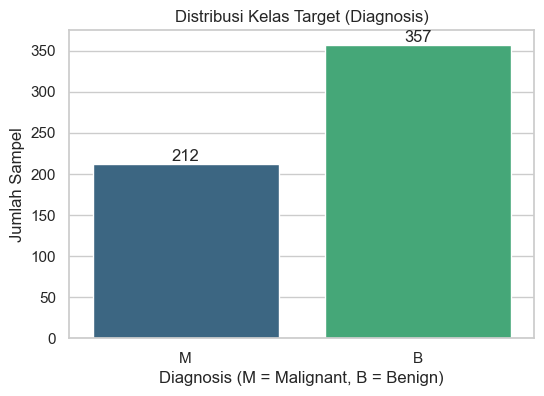

Persentase Distribusi Kelas Target:
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


In [45]:
target_col = 'diagnosis'

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x=target_col, hue=target_col, palette='viridis')
plt.title('Distribusi Kelas Target (Diagnosis)')
plt.xlabel('Diagnosis (M = Malignant, B = Benign)')
plt.ylabel('Jumlah Sampel')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom')

plt.show()

print("Persentase Distribusi Kelas Target:")
print(df[target_col].value_counts(normalize=True) * 100)

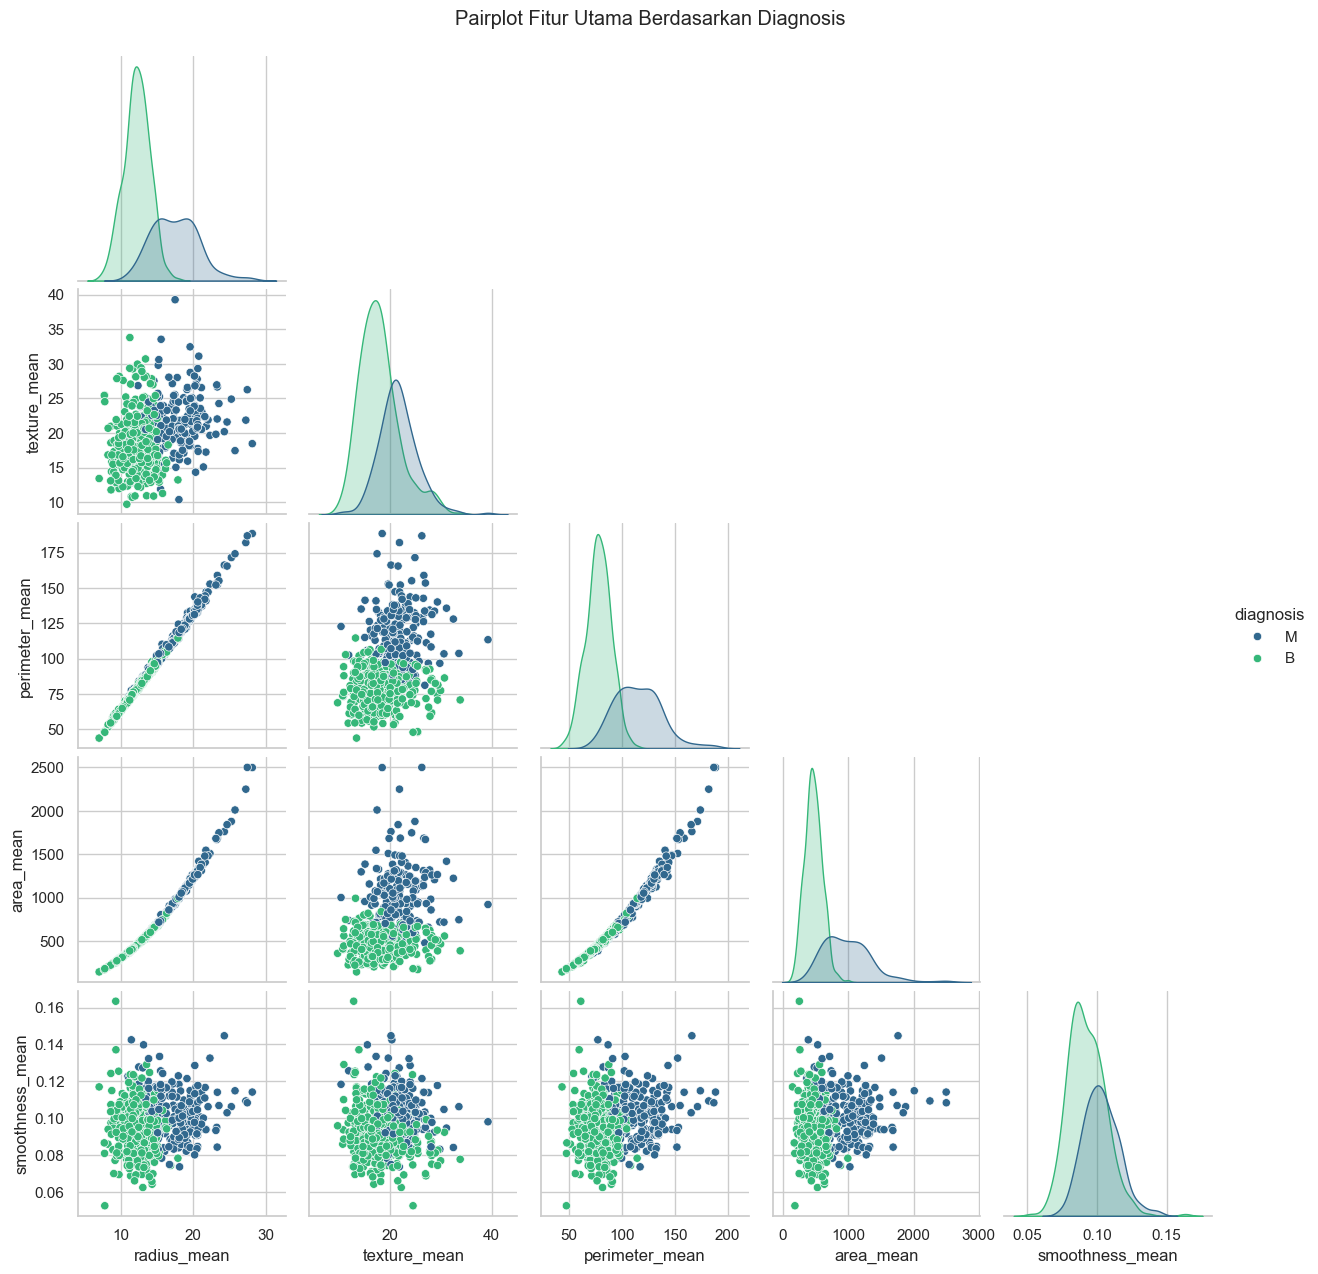

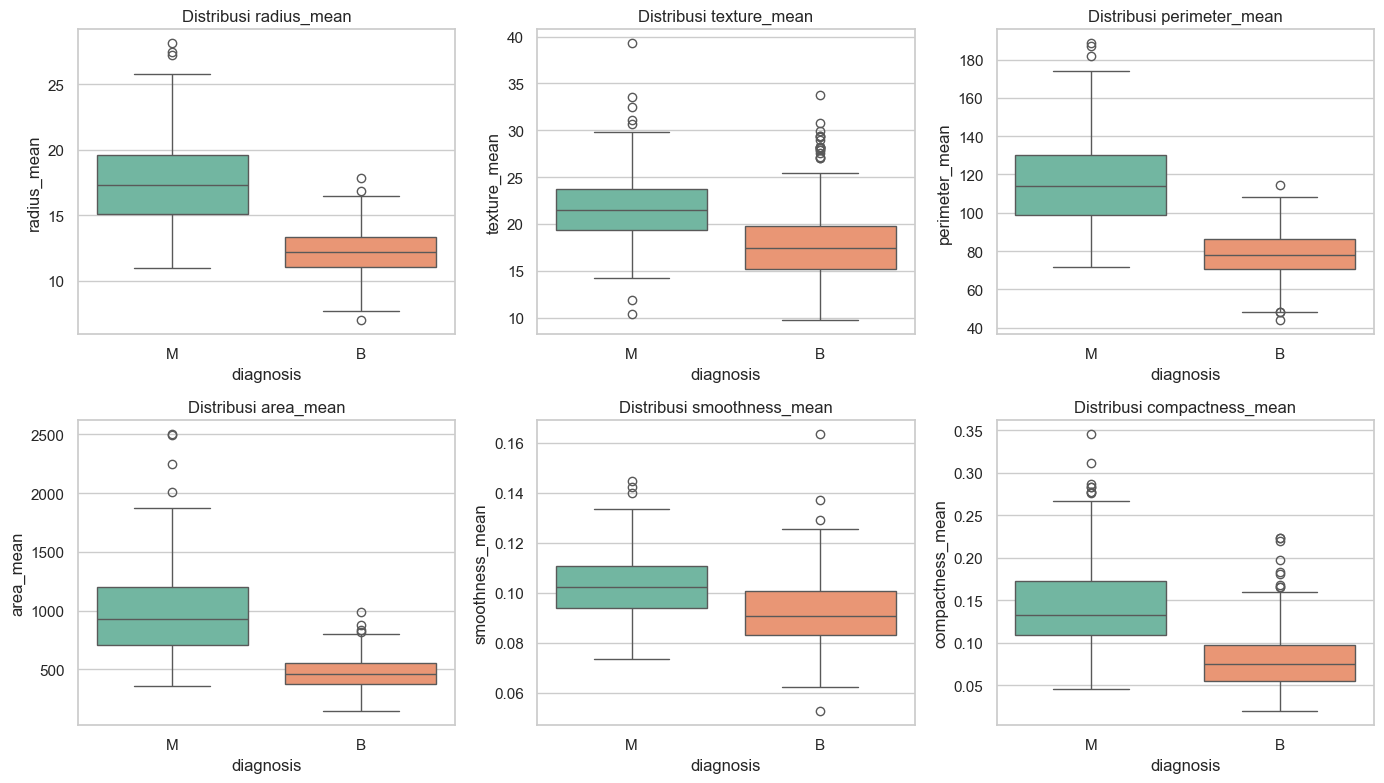

In [46]:
sample_cols = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', target_col]
sns.pairplot(df[sample_cols], hue=target_col, corner=True, palette='viridis')
plt.suptitle('Pairplot Fitur Utama Berdasarkan Diagnosis', y=1.02)
plt.show()

# Boxplot fitur numerik
num_cols = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean']

plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x=target_col, y=col, hue=target_col, palette='Set2')
    plt.title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [47]:
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

print("Total missing value setelah cleaning:", df.isnull().sum().sum())

Total missing value setelah cleaning: 0


In [48]:

df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print("Bentuk dataset setelah encoding:", df.shape)
print("Distribusi kelas target (diagnosis):")
print(df['diagnosis'].value_counts())

Bentuk dataset setelah encoding: (569, 31)
Distribusi kelas target (diagnosis):
diagnosis
0    357
1    212
Name: count, dtype: int64


In [49]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test : {X_test.shape}")

Ukuran X_train: (455, 30)
Ukuran X_test : (114, 30)


**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [50]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)


# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [51]:

svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [52]:
y_pred_linear = svm_linear.predict(X_test_scaled)

## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [53]:
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [54]:
y_pred_rbf = svm_rbf.predict(X_test_scaled)

## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [55]:
c_values = [0.01, 0.1, 1, 10, 100]
train_accuracies = []
test_accuracies = []

for C in c_values:
    model = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
    model.fit(X_train_scaled, y_train)
    
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

In [56]:
for C, tr_acc, te_acc in zip(c_values, train_accuracies, test_accuracies):
    print(f"C = {C:<5} | Train Accuracy: {tr_acc:.4f} | Test Accuracy: {te_acc:.4f}")

C = 0.01  | Train Accuracy: 0.6264 | Test Accuracy: 0.6316
C = 0.1   | Train Accuracy: 0.9538 | Test Accuracy: 0.9474
C = 1     | Train Accuracy: 0.9868 | Test Accuracy: 0.9737
C = 10    | Train Accuracy: 0.9890 | Test Accuracy: 0.9737
C = 100   | Train Accuracy: 1.0000 | Test Accuracy: 0.9649


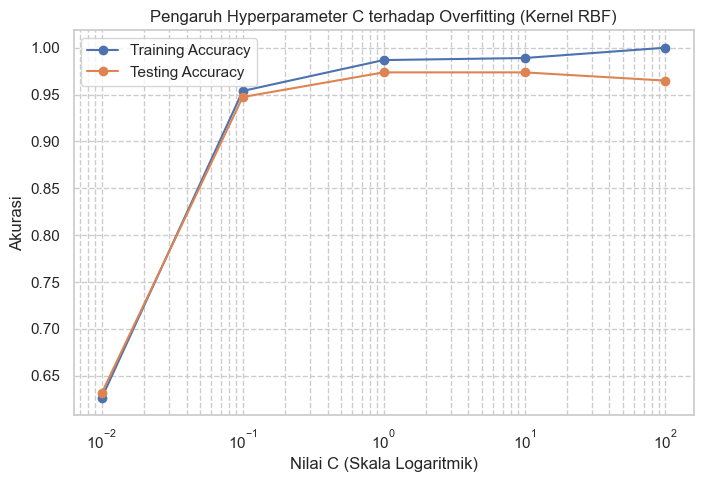

In [57]:
plt.figure(figsize=(8, 5))
plt.plot(c_values, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(c_values, test_accuracies, marker='o', label='Testing Accuracy')

plt.xscale('log')
plt.xlabel('Nilai C (Skala Logaritmik)')
plt.ylabel('Akurasi')
plt.title('Pengaruh Hyperparameter C terhadap Overfitting (Kernel RBF)')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

# 4. Evaluasi Model

In [58]:
metrics_linear = {
    'Model': 'SVM Linear',
    'Accuracy': accuracy_score(y_test, y_pred_linear),
    'Precision': precision_score(y_test, y_pred_linear),
    'Recall': recall_score(y_test, y_pred_linear),
    'F1-Score': f1_score(y_test, y_pred_linear)
}

metrics_rbf = {
    'Model': 'SVM RBF',
    'Accuracy': accuracy_score(y_test, y_pred_rbf),
    'Precision': precision_score(y_test, y_pred_rbf),
    'Recall': recall_score(y_test, y_pred_rbf),
    'F1-Score': f1_score(y_test, y_pred_rbf)
}

# Gabungkan ke dalam satu DataFrame
df_eval = pd.DataFrame([metrics_linear, metrics_rbf])
display(df_eval)

,Model,Accuracy,Precision,Recall,F1-Score
0,SVM Linear,0.964912,1.0,0.904762,0.950000
1,SVM RBF,0.973684,1.0,0.928571,0.962963


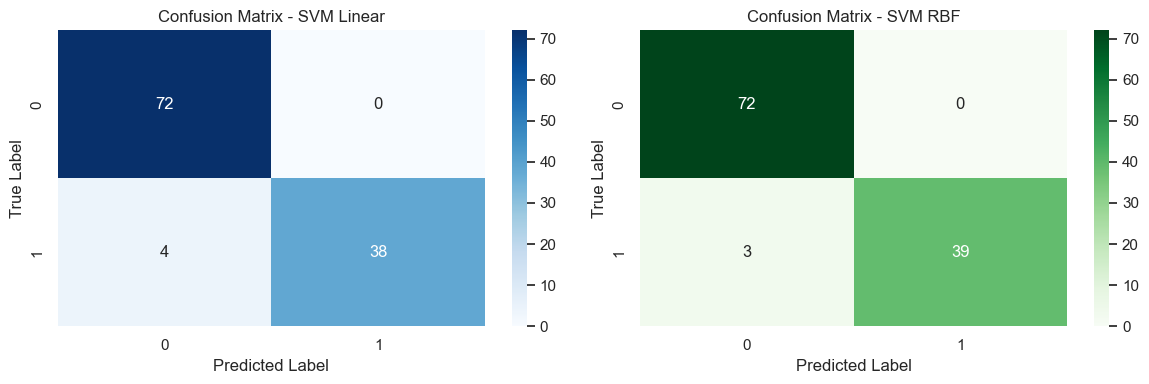

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, y_pred_linear), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - SVM Linear')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(confusion_matrix(y_test, y_pred_rbf), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix - SVM RBF')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [60]:
df_sv = pd.DataFrame({
    'Model': ['SVM Linear', 'SVM RBF'],
    'Total Support Vectors': [len(svm_linear.support_vectors_), len(svm_rbf.support_vectors_)],
    'Class 0 (Benign)': [svm_linear.n_support_[0], svm_rbf.n_support_[0]],
    'Class 1 (Malignant)': [svm_linear.n_support_[1], svm_rbf.n_support_[1]]
})

display(df_sv)

,Model,Total Support Vectors,Class 0 (Benign),Class 1 (Malignant)
0,SVM Linear,38,19,19
1,SVM RBF,107,50,57


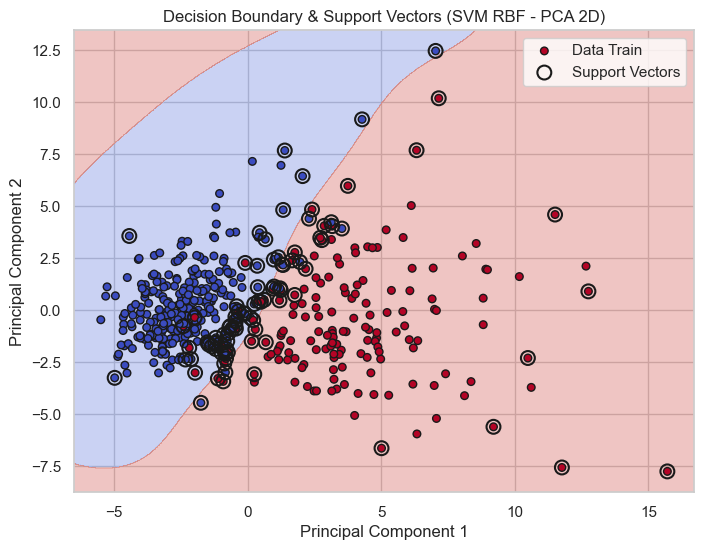

In [61]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

best_model_pca = SVC(kernel='rbf', random_state=42)
best_model_pca.fit(X_train_pca, y_train)

h = 0.02
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = best_model_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', s=30, label='Data Train')

sv = best_model_pca.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=100, facecolors='none', edgecolors='k', linewidths=1.5, label='Support Vectors')

plt.title('Decision Boundary & Support Vectors (SVM RBF - PCA 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

# 5. Analisis

Berdasarkan hasil eksperimen, perbandingan performa antara kernel Linear dan RBF menunjukkan hasil yang hampir setara dengan tingkat akurasi tinggi. Kernel RBF mencapai akurasi 97.37 persen, sedikit lebih tinggi dibandingkan kernel Linear yang mencapai akurasi 96.49 persen. Perbedaan ini tidak terlalu signifikan karena sebaran data pada eksplorasi awal menunjukkan bahwa beberapa fitur utama seperti radius mean, perimeter mean, dan area mean sudah memiliki batas pemisah antarkelas yang cukup jelas secara linear, meskipun terdapat sedikit area tumpang tindih.

Pada eksperimen parameter regularisasi C, perubahan nilai C berpengaruh langsung terhadap tingkat akurasi training dan testing. Nilai C yang terlalu kecil yaitu 0.01 menyebabkan model mengalami underfitting dengan akurasi yang rendah. Model mencapai performa terbaik dan seimbang pada nilai C sama dengan 1. Gejala overfitting mulai terlihat saat nilai C ditingkatkan menjadi 100, di mana akurasi pada data training mencapai 100 persen sempurna, tetapi akurasi pada data testing justru menurun dari 97.37 persen menjadi 96.49 persen.

Analisis jumlah support vectors memperlihatkan bahwa model kernel Linear hanya membutuhkan 38 support vectors, sedangkan model kernel RBF membutuhkan 107 support vectors. Jumlah support vectors ini berbanding lurus dengan kompleksitas batas keputusan. Kernel Linear membentuk garis atau bidang pemisah yang lebih sederhana sehingga membutuhkan lebih sedikit titik sampel, sedangkan kernel RBF membentuk batas keputusan non linear yang lebih fleksibel dan kompleks di sekitar area data yang tumpang tindih.




# 6. Kesimpulan dan Saran

Kesimpulan dari eksperimen ini adalah bahwa algoritma Support Vector Machine terbukti sangat efektif untuk klasifikasi dataset ini. Kedua jenis kernel mampu memberikan performa di atas 96 persen. Model terbaik diperoleh dengan menggunakan kernel RBF pada nilai C sama dengan 1, karena mampu memberikan keseimbangan akurasi data training dan testing tanpa mengalami overfitting.

Saran untuk eksperimen selanjutnya adalah melakukan pencarian kombinasi hyperparameter yang lebih optimal menggunakan GridSearchCV untuk menguji variasi nilai C dan gamma secara bersamaan. Selain itu, dapat dilakukan eksplorasi penggunaan kernel lain seperti Polynomial serta penerapan seleksi fitur untuk mengurangi dimensi data sebelum tahap pelatihan model.